In [ ]:
import torch
from torch import nn
from torch import optim
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

In [ ]:
# Definição da classe da rede neural
class FashionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(784, 256) # Camada oculta 1
        self.hidden2 = nn.Linear(256, 128) # Camada oculta 2
        self.output = nn.Linear(128, 10) # Camada de saída
        self.log_softmax = nn.LogSoftmax(dim=1) # Softmax com log
        self.activation = nn.ReLU() # Função de ativação ReLU

    def forward(self, x):
        x = self.hidden1(x) # Passa pelos neurônios da primeira camada oculta
        x = self.activation(x) # Aplica a função de ativação ReLU
        x = self.hidden2(x) # Passa pelos neurônios da segunda camada oculta
        x = self.activation(x) # Aplica a função de ativação ReLU
        x = self.output(x) # Passa pelos neurônios da camada de saída
        output = self.log_softmax(x) # Aplica log_softmax
        return output

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = FashionNetwork()
model.load_state_dict(torch.load('fashion_mnist_model.pt'))
model.to(device)  # Mover o modelo carregado para a GPU, se disponível

In [ ]:
  import os
  import gzip
  import numpy as np

In [ ]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(0.5, 0.5)
                              ])

# Baixar e carregar os dados de treinamento
trainset = datasets.FashionMNIST('Fashion_MNIST/', download=True,
                                 train=True, transform=transform)


# Baixar e carregar os dados de teste
testset = datasets.FashionMNIST('Fashion_MNIST/', download=True,
                                train=False, transform=transform)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
imagem, true_label =  testset[10]

plt.figure(figsize=(2, 2))

plt.imshow(imagem[0], cmap='gray')
plt.title(class_names[true_label])
plt.axis('off')
plt.show()

In [ ]:
with torch.no_grad():
  imagem = imagem.view(1, -1)
  imagem = imagem.to(device)

  log_prob = model(imagem) # O modelo retorna o logaritmo do softmax
  prob = torch.exp(log_prob) # Não quero o logaritmo então passo exp(log(x)) = x

  print(prob) # O mais provavel foi o indice 4


  print(f'\nA classe inferida é: {class_names[torch.argmax(prob)]} com {torch.max(prob)*100:.2f}% de certeza.')

### Interface melhorada

In [ ]:
# @title Texto de título padrão
import matplotlib.pyplot as plt
import numpy as np

def imshow(image, ax=None, title=None, normalize=True):
    # Cria a figura se não for especificado um eixo
    if ax is None:
        fig, ax = plt.subplots()

    # Transforma a imagem para o formato esperado pelo plt.imshow
    image = image.numpy().transpose((1, 2, 0))

    # Remove a dimensão extra se a imagem for preto e branco
    if image.shape[2] == 1:
        image = np.squeeze(image, axis=2)

    # Normaliza a imagem entre 0 e 1
    if normalize:
        mean = np.array([0.5])
        std = np.array([0.5])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    # Mostra a imagem em escala de cinza
    ax.imshow(image, cmap='gray')

    # Remove as bordas e os ticks dos eixos
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')

    return ax

def view_classify(img, ps):
    # Nomes das classes de roupas
    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

    # Converte as probabilidades para um array numpy
    ps = ps.cpu().detach().numpy().squeeze()

    # Cria a figura com dois eixos
    fig, (ax1, ax2) = plt.subplots(figsize=(6, 9), ncols=2)

    # Mostra a imagem com o plt.imshow() e em escala de cinza
    ax1.imshow(img.view(28, 28).cpu().numpy(), cmap='gray')
    ax1.axis('off')

    # Adiciona as classes correta e prevista no gráfico
    predicted_label = np.argmax(ps)

    # Plota um gráfico de barras com as probabilidades
    ax2.barh(np.arange(10), ps, color='black')
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(10))
    ax2.set_yticklabels(class_names, size='small');
    ax2.set_title(class_names[predicted_label])
    ax2.set_xlim(0, 1.1)
    ax2.set_ylim(-0.5, 9.5)


    plt.tight_layout()

In [ ]:
imagem, true_label = testset[500]

with torch.no_grad():
  imagem = imagem.view(1, -1)
  imagem = imagem.to(device)

  log_prob = model(imagem) # O modelo retorna o logaritmo do softmax
  prob = torch.exp(log_prob) # Não quero o logaritmo então passo exp(log(x)) = x

print(f'Verdade absoluta: {class_names[true_label]}')
view_classify(imagem.view(1, 28, 28), prob)

In [ ]:
# @title Pegar uma imagem da internet
from google.colab import files
from PIL import Image
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms

# Define as transformações aplicadas às imagens
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Faz o upload da imagem para a sessão atual
uploaded = files.upload()

# Obtém o nome do arquivo carregado
filename = list(uploaded.keys())[0]

# Carrega a imagem usando o caminho do arquivo carregado
image = Image.open(filename)

# Transforma a imagem em um tensor
image_tensor = transform(image)

# Cria um conjunto de dados com a imagem
dataset = TensorDataset(image_tensor)

# Cria o DataLoader com o conjunto de dados e o tamanho do lote
dataloader = DataLoader(dataset, batch_size=1)

# Cria o iterador para o DataLoader
dataloader_iterator = iter(dataloader)

# Obtém o próximo lote de dados
image = next(dataloader_iterator)

# Flatten the image tensor
image = image[0].view(1, -1)

# Move a imagem para a GPU, se disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image = image.to(device)

# Realiza a inferência
with torch.no_grad():
    log_ps = model(image)
    ps = torch.exp(log_ps)
    predicted_label = torch.argmax(ps)

# Move a imagem e as probabilidades de volta para a CPU
image = image.squeeze(0).to('cpu')
ps = ps.squeeze(0).to('cpu')

# Exibe a imagem e a classe prevista
view_classify(image.view(1, 28, 28), ps)

### Revisão sobre MLP usando Pytorch

#### Regressão

In [ ]:
import torch
import numpy as np
from torch import nn, optim, from_numpy
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import joblib

In [ ]:
class BostonDataset(torch.utils.data.Dataset):
    def __init__(self, scale_data=True):

        xy = np.loadtxt('./data/BostonHousing.csv',skiprows=1,
                        delimiter=';', dtype=np.float32)
        self.xy = xy # para demonsrar o uso do scaler a posteriori (não precisa guardar)
        self.len = xy.shape[0]

        self.x_data = xy[:, 0:-1]
        self.y_data = xy[:, -1:]

        # Aplicar o escalonamento caso necessário
        if scale_data:
          self.x_scaler = StandardScaler()
          self.y_scaler = StandardScaler()
          self.x_data = self.x_scaler.fit_transform(self.x_data)
          self.y_data = self.y_scaler.fit_transform(self.y_data)
          # Salvar o objeto de escala para uso posterior
          joblib.dump(self.x_scaler, 'x_scaler.pkl')
          joblib.dump(self.y_scaler, 'y_scaler.pkl')

        self.x_data = from_numpy(self.x_data)
        self.y_data = from_numpy(self.y_data)

    def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

    def __len__(self):
        return self.len

In [ ]:
dataset = BostonDataset()
train_loader = torch.utils.data.DataLoader(dataset, batch_size=100, shuffle=True, num_workers=0)

In [ ]:
### Demonstração
# Como carregar o scaler a posteriori
x_scaler = joblib.load('x_scaler.pkl')
y_scaler = joblib.load('y_scaler.pkl')

xy = dataset.xy #podem ser novos dados como os de validação
x_new = xy[:, 0:-1]
y_new = xy[:, -1:]

# Usando o scaler em novos dados
x_new = x_scaler.transform(x_new)
y_new = y_scaler.transform(y_new)

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
          nn.Linear(13, 64),
          nn.ReLU(),
          nn.Linear(64, 32),
          nn.ReLU(),
          nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.layers(x)

In [ ]:
model = MLP()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1E-4)

In [ ]:
%%time
# Loop de treinamento
for epoch in range(10000):
    loss_batch = 0
    for i, data in enumerate(train_loader):
        # obter as entradas
        inputs, labels = data

        # Propagação para frente
        y_pred = model(inputs)

        # Calcular e imprimir o loss
        loss = criterion(y_pred, labels)
        loss_batch += loss
        #if (epoch+1)%250 == 0 or epoch == 0:
        #    print(f'Epoch {epoch + 1} | Batch: {i+1} | Loss: {loss.item():.4f}')

        # Backpropagation e atualização dos pesos
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch+1)%250 == 0 or epoch == 0:
        print(f'epoch: {epoch+1} | loss: {loss_batch}')

Validando com um dado externo

In [ ]:
xy = np.loadtxt('./data/BostonHousing.csv',skiprows=1,
                        delimiter=';', dtype=np.float32)

# Como carregar o scaler a posteriori
x_scaler = joblib.load('x_scaler.pkl')
y_scaler = joblib.load('y_scaler.pkl')

xy = dataset.xy #podem ser novos dados como os de validação
x_new = xy[:, 0:-1]
y_new = xy[:, -1:]

# Usando o scaler em novos dados
x_new = x_scaler.transform(x_new)
y_new = y_scaler.transform(y_new)

idx = 20
x_val = dataset.x_data[idx]
y_val = dataset.y_data[idx]

print('Dados sem a escala')
print(xy[idx,:])
print(xy[idx,-1])

print('Dados com a escala')
print(x_val)
print(y_val)

print('Previsão feita: ')
with torch.no_grad():
   print( model(x_val), y_val )

#### Classificador binário

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch import nn, from_numpy, optim
import torch
import numpy as np

In [ ]:
class DiabetesDataset(Dataset):
    def __init__(self):
      # Este dataset já está escalonado, por isso não entramos com o scaler!
        xy = np.loadtxt('./data/diabetes.csv',
                        delimiter=',', dtype=np.float32)
        self.len = xy.shape[0]
        self.x_data = from_numpy(xy[:, 0:-1])
        self.y_data = from_numpy(xy[:, [-1]])

    def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

    def __len__(self):
        return self.len

In [ ]:
# Classificação Binária
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size[0]),
            nn.ReLU(),
            #nn.Dropout(p=0.5),
            nn.Linear(hidden_size[0], hidden_size[1]),
            nn.ReLU(),
            #nn.Dropout(p=0.5),
            nn.Linear(hidden_size[1], 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.layers(x)

In [ ]:
# Declaração do Dataloader e inicialização do barh
dataset = DiabetesDataset()
train_loader = DataLoader(dataset=dataset,
                          batch_size=32,
                          shuffle=True,
                          num_workers=0)

In [ ]:
model = MLP(input_size=8, hidden_size=(32,16))
criterion = nn.BCELoss(reduction='mean')
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
# Loop de treinamento
for epoch in range(1000):
    for i, data in enumerate(train_loader):
        # obter as entradas
        inputs, labels = data

        # Propagação para frente
        y_pred = model(inputs)

        # Calcular e imprimir o loss
        loss = criterion(y_pred, labels)
        if (epoch+1)%250 == 0:
            print(f'Epoch {epoch + 1} | Batch: {i+1} | Loss: {loss.item():.4f}')

        # Backpropagation e atualização dos pesos
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


#### Classificador de múltiplas classes

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch import nn, from_numpy, tensor, optim
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

In [ ]:
class WineDataset(Dataset):

    def __init__(self, scale_data=True):
        xy = np.loadtxt('./data/wine.csv',
                        delimiter=',', dtype=np.float32, skiprows=1)

        self.len = xy.shape[0]
        self.x_data = xy[:, 1:]
        self.y_data = xy[:, 0]-1 # começar em zero

        # Aplicar o escalonamento caso necessário
        if scale_data:
          self.x_scaler = StandardScaler()
          self.x_data = self.x_scaler.fit_transform(self.x_data)
          # Salvar o objeto de escala para uso posterior
          joblib.dump(self.x_scaler, 'x_scaler.pkl')

        self.x_data = from_numpy(self.x_data)
        self.y_data = from_numpy(self.y_data)

    def __getitem__(self, index):
        return self.x_data[index,:], self.y_data[index].long()

    def __len__(self):
        return self.len

In [ ]:
# Problema multiclasse
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
             nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
            # Não precisa colocar o softmax - aqui se tem os logits
        )
    def forward(self, x):
        return self.layers(x)

In [ ]:
dataset = WineDataset()
train_loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

model = MLP(input_size=13, hidden_size=32, num_classes=3)
criterion = nn.CrossEntropyLoss()  # aplica a função Softmax
optimizer = optim.Adam(model.parameters(), lr=1E-2)

In [ ]:
# Loop de treinamento
for epoch in range(1000):
    for i, data in enumerate(train_loader):
        # obter as entradas
        inputs, labels = data

        # Propagação para frente
        y_pred = model(inputs)

        # Calcular e imprimir o loss
        loss = criterion(y_pred, labels)
        if (epoch+1)%250 == 0 or epoch == 0:
            print(f'Epoch {epoch + 1} | Batch: {i+1} | Loss: {loss.item()}')

        # Backpropagation e atualização dos pesos
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Validando com um dado externo

In [ ]:
xy = np.loadtxt('./data/wine.csv',skiprows=1,
                        delimiter=',', dtype=np.float32)

# Como carregar o scaler a posteriori
x_scaler = joblib.load('x_scaler.pkl')

#podem ser novos dados como os de validação
x_new = xy[:, 1:]
y_new = xy[:, 0] -1 # tem que começar em zero!

# Usando o scaler em novos dados
x_new = x_scaler.transform(x_new)

idx = 20
x_val = dataset.x_data[idx]
y_val = dataset.y_data[idx]

print('Dados sem a escala')
print(xy[idx,1:])
print(xy[idx,0]-1)

print(100*'*')

print('Dados com a escala')
print(x_val)
print(y_val)

In [ ]:
m = nn.Softmax(dim=0)

In [ ]:
print(100*'*')

print('Previsão feita: ')
with torch.no_grad():
   print( model(x_val), '|', m(model(x_val)), '|', y_val.item() )

#### Para não ter overfitting temos que considerar treino e teste

In [ ]:
from torch.utils.data import Dataset, DataLoader, random_split
from torch import nn, from_numpy, tensor, optim
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import joblib

import os
# Criar a pasta 'pesos' se ela não existir
if not os.path.exists('pesos'):
    os.makedirs('pesos')

dataset = WineDataset()

# Dividir o conjunto de dados em conjuntos de treinamento e teste
tamanho_treino = int(0.8 * len(dataset))  # 80% para treinamento
tamanho_teste = len(dataset) - tamanho_treino  # 20% para teste
conjunto_treino, conjunto_teste = random_split(dataset, [tamanho_treino, tamanho_teste])

# Criar carregadores de dados para os conjuntos de treinamento e teste
carregador_treino = torch.utils.data.DataLoader(conjunto_treino, batch_size=32, shuffle=True, num_workers=0)
carregador_teste = torch.utils.data.DataLoader(conjunto_teste, batch_size=32, shuffle=False, num_workers=0)

modelo = MLP(input_size=13, hidden_size=32, num_classes=3)
criterio = nn.CrossEntropyLoss()  # aplica a função Softmax
otimizador = optim.Adam(modelo.parameters(), lr=1E-2)

# Loop de treinamento
for epoca in range(1000):
    for i, dados in enumerate(carregador_treino):
        # obter as entradas
        entradas, rotulos = dados

        # Propagação para frente
        y_pred = modelo(entradas)

        # Calcular e imprimir a perda
        perda = criterio(y_pred, rotulos)
        if (epoca+1)%250 == 0 or epoca == 0:
            print(f'Época {epoca + 1} | Lote: {i+1} | Perda: {perda.item()}')

        # Backpropagation e atualização dos pesos
        otimizador.zero_grad()
        perda.backward()
        otimizador.step()

    # Calcular a acurácia no conjunto de treinamento
    if (epoca+1)%250 == 0 or epoca == 0:
      # Salvar os pesos da rede ao longo das épocas
      torch.save(modelo.state_dict(), f'pesos/pesos_epoca_{epoca+1}.pth') # IMPORTANTE!!!!!!!!!!!!
      with torch.no_grad():
          y_pred_treino = modelo(conjunto_treino[:][0])
          acuracia_treino = accuracy_score(conjunto_treino[:][1].numpy(), y_pred_treino.argmax(dim=1).numpy())
          y_pred_teste = modelo(conjunto_teste[:][0])
          acuracia_teste = accuracy_score(conjunto_teste[:][1].numpy(), y_pred_teste.argmax(dim=1).numpy())
          print(f'Acurácia de Treinamento: {acuracia_treino} | Acurácia de Teste: {acuracia_teste}')

Usando a posteriori

In [ ]:
# Problema multiclasse
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
             nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
            # Não precisa colocar o softmax - aqui se tem os logits
        )
    def forward(self, x):
        return self.layers(x)

In [ ]:
# Carregar os pesos da rede
modelo_carregado = MLP(input_size=13, hidden_size=32, num_classes=3)
modelo_carregado.load_state_dict(torch.load('pesos/pesos_epoca_1000.pth'))
modelo_carregado.eval()  # Colocar em modo de avaliação

In [ ]:
xy = np.loadtxt('./data/wine.csv',skiprows=1,
                        delimiter=',', dtype=np.float32)

# Como carregar o scaler a posteriori
x_scaler = joblib.load('x_scaler.pkl')

#podem ser novos dados como os de validação
x_new = xy[:, 1:]
y_new = xy[:, 0] -1 # tem que começar em zero!

# Usando o scaler em novos dados
x_new = x_scaler.transform(x_new)

idx = 100
x_val = dataset.x_data[idx]
y_val = dataset.y_data[idx]

m = nn.Softmax(dim=0)

print(100*'*')

print('Previsão feita: ')
with torch.no_grad():
   print( model(x_val), '|', m(model(x_val)), '|', y_val.item() )

## Parte 3

### Redes Convolucionais

In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import json
import requests

In [ ]:
# Função para carregar uma imagem local e aplicar as transformações necessárias
def load_image(image_path, transform):
    image = Image.open(image_path).convert('RGB')
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    return transform(image)

In [ ]:
# Define as transformações de imagem
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
# Baixa o mapeamento de índices para rótulos do ImageNet
imagenet_labels_url = 'https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json'
response = requests.get(imagenet_labels_url)
imagenet_labels = json.loads(response.text)

In [ ]:
imagenet_labels

In [8]:
# Carrega a rede AlexNet e define-a para o modo de avaliação
alexnet = models.alexnet(pretrained=True)
alexnet.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

Saving bobby.jpg to bobby (2).jpg


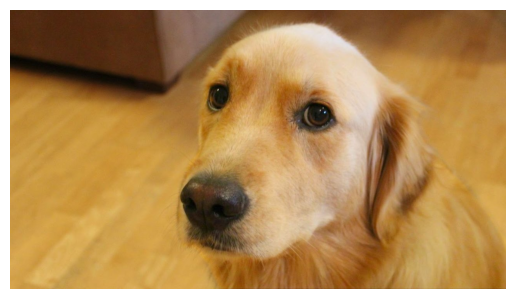

In [9]:
# Carrega a imagem e aplica a AlexNet para obter as classificações
uploaded = files.upload()
image_name = list(uploaded.keys())[0]
image_tensor = load_image(image_name, transform).unsqueeze(0)

In [10]:
image_tensor.shape

torch.Size([1, 3, 224, 224])

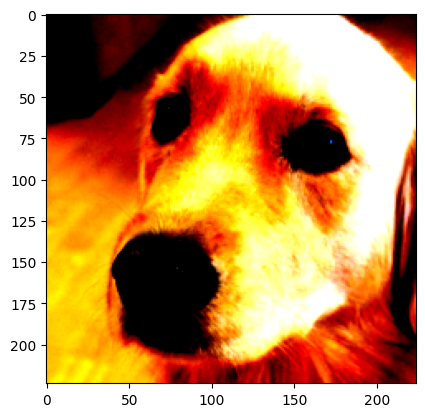

In [21]:
plt.imshow(image_tensor.numpy()[0].transpose(1, 2, 0))

In [22]:
with torch.no_grad():
    output = alexnet(image_tensor)
    probabilities = torch.nn.functional.softmax(output, dim=1)
    top_prob, top_class = probabilities.topk(1, dim=1)
    class_label = imagenet_labels[top_class.item()]
    print(f'Top class: {class_label}, probability: {top_prob.item()}')

Top class: Golden Retriever, probability: 0.9314801096916199


In [23]:
with torch.no_grad():
    output = alexnet(image_tensor)
    probabilities = torch.nn.functional.softmax(output, dim=1)
    top_prob, top_class = probabilities.topk(10, dim=1)
    for tc, tp in zip(top_class[0], top_prob[0]):
      class_label = imagenet_labels[tc.item()]
      print(f'{class_label}: {100*tp.item(): .2f}%')

Golden Retriever:  93.15%
Labrador Retriever:  4.65%
tennis ball:  0.51%
Saluki:  0.35%
Cocker Spaniels:  0.29%
Beagle:  0.15%
Pembroke Welsh Corgi:  0.10%
Chihuahua:  0.09%
Brittany Spaniel:  0.09%
Shetland Sheepdog:  0.09%


Saving Captura de tela 2026-04-23 111921.png to Captura de tela 2026-04-23 111921.png


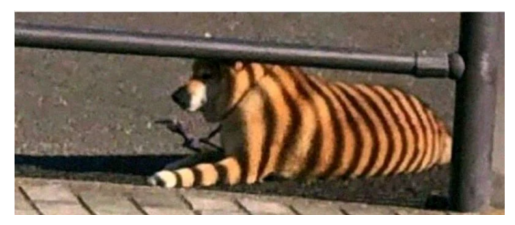

In [29]:
# Carrega a imagem e aplica a AlexNet para obter as classificações
uploaded = files.upload()
image_name = list(uploaded.keys())[0]
image_tensor = load_image(image_name, transform).unsqueeze(0)

In [30]:
with torch.no_grad():
    output = alexnet(image_tensor)
    probabilities = torch.nn.functional.softmax(output, dim=1)
    top_prob, top_class = probabilities.topk(10, dim=1)
    for tc, tp in zip(top_class[0], top_prob[0]):
      class_label = imagenet_labels[tc.item()]
      print(f'{class_label}: {100*tp.item(): .2f}%')

tiger:  77.61%
tiger cat:  8.10%
fire screen sheet:  3.39%
pan flute:  3.20%
monarch butterfly:  0.53%
doormat:  0.50%
stove:  0.35%
harmonica:  0.33%
buckle:  0.22%
scabbard:  0.17%
